In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel('GasData.xlsx')

# Rename columns for easier access
df.columns = ['Year', 'G', 'P', 'Y']

# Create log transformations
df['ln_G'] = np.log(df['G'])
df['ln_P'] = np.log(df['P'])
df['ln_Y'] = np.log(df['Y'])

### Part A

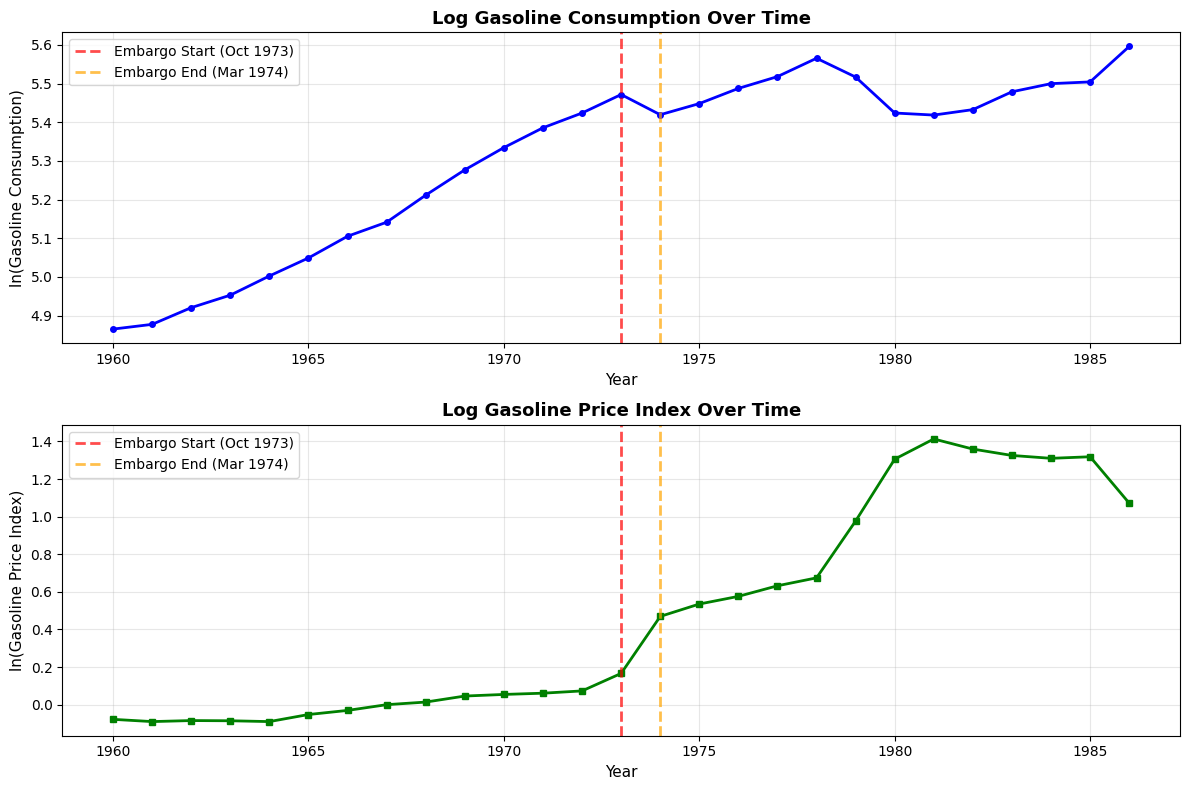

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot ln(G)
ax1.plot(df['Year'], df['ln_G'], marker='o', linewidth=2, markersize=4, color='blue')
ax1.axvline(x=1973, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Embargo Start (Oct 1973)')
ax1.axvline(x=1974, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Embargo End (Mar 1974)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('ln(Gasoline Consumption)', fontsize=11)
ax1.set_title('Log Gasoline Consumption Over Time', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot ln(P)
ax2.plot(df['Year'], df['ln_P'], marker='s', linewidth=2, markersize=4, color='green')
ax2.axvline(x=1973, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Embargo Start (Oct 1973)')
ax2.axvline(x=1974, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Embargo End (Mar 1974)')
ax2.set_xlabel('Year', fontsize=11)
ax2.set_ylabel('ln(Gasoline Price Index)', fontsize=11)
ax2.set_title('Log Gasoline Price Index Over Time', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()

### Part B

In [7]:
# Baseline model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + u_t
X_levels = sm.add_constant(df[['ln_P', 'ln_Y']])
y_levels = df['ln_G']
model_levels = OLS(y_levels, X_levels).fit()

print("\n--- BASELINE MODEL (LEVELS) ---")
print(model_levels.summary())

# First differences model
df['d_ln_G'] = df['ln_G'].diff()
df['d_ln_P'] = df['ln_P'].diff()
df['d_ln_Y'] = df['ln_Y'].diff()

# Drop first observation (NA after differencing)
df_diff = df.dropna(subset=['d_ln_G', 'd_ln_P', 'd_ln_Y']).copy()

X_diff = sm.add_constant(df_diff[['d_ln_P', 'd_ln_Y']])
y_diff = df_diff['d_ln_G']
model_diff = OLS(y_diff, X_diff).fit()

print("\n--- FIRST DIFFERENCES MODEL ---")
print(model_diff.summary())


--- BASELINE MODEL (LEVELS) ---
                            OLS Regression Results                            
Dep. Variable:                   ln_G   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     616.4
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           2.35e-21
Time:                        22:34:10   Log-Likelihood:                 55.158
No. Observations:                  27   AIC:                            -104.3
Df Residuals:                      24   BIC:                            -100.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.89

In [9]:
print("\n--- COMPARISON OF ESTIMATES ---")
comparison_df = pd.DataFrame({
    'Levels Model': [model_levels.params['const'], model_levels.params['ln_P'], model_levels.params['ln_Y']],
    'Levels SE': [model_levels.bse['const'], model_levels.bse['ln_P'], model_levels.bse['ln_Y']],
    'First Diff Model': [model_diff.params['const'], model_diff.params['d_ln_P'], model_diff.params['d_ln_Y']],
    'First Diff SE': [model_diff.bse['const'], model_diff.bse['d_ln_P'], model_diff.bse['d_ln_Y']]
}, index=['Constant', 'Price Elasticity', 'Income Elasticity'])
print(comparison_df.to_string())

print("\n--- IMPLICATIONS FOR THE PROCESS u_t ---")
print(f"\nLevels Model R²: {model_levels.rsquared:.4f}")
print(f"First Differences R²: {model_diff.rsquared:.4f}")


--- COMPARISON OF ESTIMATES ---
                   Levels Model  Levels SE  First Diff Model  First Diff SE
Constant              -9.898955   0.626226          0.019764       0.006799
Price Elasticity      -0.160382   0.021982         -0.233314       0.034476
Income Elasticity      1.691745   0.070300          0.836958       0.222560

--- IMPLICATIONS FOR THE PROCESS u_t ---

Levels Model R²: 0.9809
First Differences R²: 0.8169


### Part C

In [11]:
# H0: β1 = 0 (perfectly inelastic)
# H1: β1 < 0 (elastic, one-tailed test)
beta1 = model_levels.params['ln_P']
se_beta1 = model_levels.bse['ln_P']
t_stat = beta1 / se_beta1
df_resid = model_levels.df_resid

# One-tailed p-value
p_value_one_tailed = stats.t.cdf(t_stat, df_resid)

print(f"\nNull Hypothesis (H0): β1 = 0 (perfectly price inelastic)")
print(f"Alternative Hypothesis (H1): β1 < 0 (price elastic)")
print(f"\nEstimated β1 (price elasticity): {beta1:.4f}")
print(f"Standard Error: {se_beta1:.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"One-tailed p-value: {p_value_one_tailed:.4f}")

if p_value_one_tailed < 0.05:
    print(f"\n✓ Reject H0 at 5% level: Demand is NOT perfectly price inelastic")
else:
    print(f"\n✗ Fail to reject H0: Cannot conclude demand is price elastic")


Null Hypothesis (H0): β1 = 0 (perfectly price inelastic)
Alternative Hypothesis (H1): β1 < 0 (price elastic)

Estimated β1 (price elasticity): -0.1604
Standard Error: 0.0220
t-statistic: -7.2961
One-tailed p-value: 0.0000

✓ Reject H0 at 5% level: Demand is NOT perfectly price inelastic


In the time series setting, the following assumptions are needed:
- E[u_t | P_t, Y_t] = 0 (strict exogeneity)
- Var(u_t | P_t, Y_t) = σ² (homoskedasticity)
- Cov(u_t, u_s | P, Y) = 0 for t ≠ s (no serial correlation)
- The error term u_t is normally distributed (for exact inference)
- No perfect multicollinearity

Note: Serial correlation in u_t would invalidate standard errors, requiring robust or HAC (Newey-West) standard errors.

### Part D

In [12]:
# H0: β2 = 1 (unit elastic)
# H1: β2 ≠ 1 (two-tailed test)
beta2 = model_levels.params['ln_Y']
se_beta2 = model_levels.bse['ln_Y']
t_stat_income = (beta2 - 1) / se_beta2
p_value_two_tailed = 2 * (1 - stats.t.cdf(abs(t_stat_income), df_resid))

print(f"\nNull Hypothesis (H0): β2 = 1 (unit elastic in income)")
print(f"Alternative Hypothesis (H1): β2 ≠ 1")
print(f"\nEstimated β2 (income elasticity): {beta2:.4f}")
print(f"Standard Error: {se_beta2:.4f}")
print(f"t-statistic: {t_stat_income:.4f}")
print(f"Two-tailed p-value: {p_value_two_tailed:.4f}")

if p_value_two_tailed < 0.05:
    print(f"\n✓ Reject H0 at 5% level: Income elasticity is significantly different from 1")
    if beta2 > 1:
        print("  Gasoline is a luxury good (income elastic)")
    else:
        print("  Gasoline is a necessity (income inelastic)")
else:
    print(f"\n✗ Fail to reject H0: Income elasticity is not significantly different from 1")


Null Hypothesis (H0): β2 = 1 (unit elastic in income)
Alternative Hypothesis (H1): β2 ≠ 1

Estimated β2 (income elasticity): 1.6917
Standard Error: 0.0703
t-statistic: 9.8398
Two-tailed p-value: 0.0000

✓ Reject H0 at 5% level: Income elasticity is significantly different from 1
  Gasoline is a luxury good (income elastic)


### Part E

In [13]:
# Create pre-embargo indicator (PE = 1 if Year < 1973, 0 otherwise)
df['PE'] = (df['Year'] < 1973).astype(int)
df['PE_ln_P'] = df['PE'] * df['ln_P']
df['PE_ln_Y'] = df['PE'] * df['ln_Y']

# Estimate model with interactions
X_embargo = sm.add_constant(df[['ln_P', 'ln_Y', 'PE', 'PE_ln_P', 'PE_ln_Y']])
y_embargo = df['ln_G']
model_embargo = OLS(y_embargo, X_embargo).fit()

print("\n--- EMBARGO INTERACTION MODEL ---")
print("Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*PE_t + β4*PE_t*ln(P_t) + β5*PE_t*ln(Y_t) + u_t")
print(model_embargo.summary())


--- EMBARGO INTERACTION MODEL ---
Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*PE_t + β4*PE_t*ln(P_t) + β5*PE_t*ln(Y_t) + u_t
                            OLS Regression Results                            
Dep. Variable:                   ln_G   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     445.0
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.48e-20
Time:                        22:38:02   Log-Likelihood:                 64.798
No. Observations:                  27   AIC:                            -117.6
Df Residuals:                      21   BIC:                            -109.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975

In [14]:
print("\n--- COMPARISON OF PRICE ELASTICITY ESTIMATES ---")
beta1_baseline = model_levels.params['ln_P']
beta1_embargo = model_embargo.params['ln_P']
print(f"Baseline model β1 (price elasticity): {beta1_baseline:.4f}")
print(f"Embargo model β1 (post-embargo price elasticity): {beta1_embargo:.4f}")
print(f"Difference: {beta1_embargo - beta1_baseline:.4f}")

# F-test for joint significance of PE terms
# H0: β3 = β4 = β5 = 0
hypotheses = 'PE = 0, PE_ln_P = 0, PE_ln_Y = 0'
f_test = model_embargo.f_test(hypotheses)

print("\n--- F-TEST: JOINT SIGNIFICANCE OF EMBARGO EFFECTS ---")
print(f"Null Hypothesis (H0): β3 = β4 = β5 = 0")
print(f"  (Demand was unaffected by the oil embargo)")
f_stat_value = f_test.fvalue[0] if isinstance(f_test.fvalue, np.ndarray) else f_test.fvalue
print(f"\nF-statistic: {f_stat_value:.4f}")
print(f"p-value: {f_test.pvalue:.4f}")

if f_test.pvalue < 0.05:
    print(f"\n✓ Reject H0 at 5% level: The oil embargo had a SIGNIFICANT effect on gasoline demand")
    print("  The structural relationship between gasoline demand and its determinants")
    print("  changed significantly after the embargo.")
else:
    print(f"\n✗ Fail to reject H0: Cannot conclude the embargo affected demand structure")


--- COMPARISON OF PRICE ELASTICITY ESTIMATES ---
Baseline model β1 (price elasticity): -0.1604
Embargo model β1 (post-embargo price elasticity): -0.1427
Difference: 0.0177

--- F-TEST: JOINT SIGNIFICANCE OF EMBARGO EFFECTS ---
Null Hypothesis (H0): β3 = β4 = β5 = 0
  (Demand was unaffected by the oil embargo)

F-statistic: 7.2958
p-value: 0.0016

✓ Reject H0 at 5% level: The oil embargo had a SIGNIFICANT effect on gasoline demand
  The structural relationship between gasoline demand and its determinants
  changed significantly after the embargo.


### Part F

In [15]:
# Pre-embargo: β1 + β4
# Post-embargo: β1
elasticity_pre = model_embargo.params['ln_P'] + model_embargo.params['PE_ln_P']
elasticity_post = model_embargo.params['ln_P']

# Standard errors using delta method
var_pre = (model_embargo.cov_params().loc['ln_P', 'ln_P'] + 
           model_embargo.cov_params().loc['PE_ln_P', 'PE_ln_P'] + 
           2 * model_embargo.cov_params().loc['ln_P', 'PE_ln_P'])
se_pre = np.sqrt(var_pre)
se_post = model_embargo.bse['ln_P']

print("\n--- ESTIMATED PRICE ELASTICITIES ---")
print(f"\nPre-Embargo (< 1973):")
print(f"  Elasticity: {elasticity_pre:.4f}")
print(f"  Standard Error: {se_pre:.4f}")
print(f"  95% CI: [{elasticity_pre - 1.96*se_pre:.4f}, {elasticity_pre + 1.96*se_pre:.4f}]")

print(f"\nPost-Embargo (≥ 1973):")
print(f"  Elasticity: {elasticity_post:.4f}")
print(f"  Standard Error: {se_post:.4f}")
print(f"  95% CI: [{elasticity_post - 1.96*se_post:.4f}, {elasticity_post + 1.96*se_post:.4f}]")

print(f"\nChange in elasticity: {elasticity_post - elasticity_pre:.4f}")
print(f"  (More negative = more elastic = more responsive to price)")

if abs(elasticity_post) > abs(elasticity_pre):
    print("\n✓ Demand became MORE price elastic after the embargo")
    print("  Consumers became more sensitive to price changes")
else:
    print("\n✓ Demand became LESS price elastic after the embargo")
    print("  Consumers became less sensitive to price changes")



--- ESTIMATED PRICE ELASTICITIES ---

Pre-Embargo (< 1973):
  Elasticity: 0.9379
  Standard Error: 0.4072
  95% CI: [0.1399, 1.7360]

Post-Embargo (≥ 1973):
  Elasticity: -0.1427
  Standard Error: 0.0249
  95% CI: [-0.1915, -0.0939]

Change in elasticity: -1.0807
  (More negative = more elastic = more responsive to price)

✓ Demand became LESS price elastic after the embargo
  Consumers became less sensitive to price changes


### Part G

In [16]:
# Get residuals from both models
resid_baseline = model_levels.resid
resid_embargo = model_embargo.resid

# Test for AR(1): regress u_t on u_(t-1)
def test_ar1(residuals, model_name):
    print(f"\n--- {model_name} ---")
    resid_df = pd.DataFrame({'resid': residuals, 'resid_lag': residuals.shift(1)})
    resid_df = resid_df.dropna()
    
    X_ar = sm.add_constant(resid_df['resid_lag'])
    y_ar = resid_df['resid']
    ar1_model = OLS(y_ar, X_ar).fit()
    
    rho = ar1_model.params['resid_lag']
    se_rho = ar1_model.bse['resid_lag']
    t_stat = rho / se_rho
    p_value = ar1_model.pvalues['resid_lag']
    
    print(f"AR(1) coefficient (ρ): {rho:.4f}")
    print(f"Standard Error: {se_rho:.4f}")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Durbin-Watson: {durbin_watson(residuals):.4f}")
    
    if p_value < 0.05:
        print(f"✓ Reject H0: Significant evidence of AR(1) errors (ρ ≠ 0)")
        if rho > 0:
            print("  Positive serial correlation detected")
        else:
            print("  Negative serial correlation detected")
    else:
        print(f"✗ Fail to reject H0: No significant evidence of AR(1) errors")
    
    return rho, p_value

rho_baseline, p_baseline = test_ar1(resid_baseline, "BASELINE MODEL")
rho_embargo, p_embargo = test_ar1(resid_embargo, "EMBARGO MODEL")

print("\n--- DISCUSSION: STATIC MODEL ASSUMPTION ---")
print("A static model assumes errors are serially uncorrelated: E[u_t * u_s] = 0 for t ≠ s")
print("\nEvidence:")
if p_baseline < 0.05 or p_embargo < 0.05:
    print("✗ The data REJECT the static model assumption")
    print("  Significant serial correlation suggests:")
    print("  1. Omitted dynamics (lagged dependent variables)")
    print("  2. Persistent shocks affecting demand over time")
    print("  3. Standard errors are understated (should use HAC/Newey-West)")
    print("  4. A dynamic model may be more appropriate")
else:
    print("✓ The data support the static model assumption")
    print("  No significant serial correlation detected")


--- BASELINE MODEL ---
AR(1) coefficient (ρ): 0.7740
Standard Error: 0.1367
t-statistic: 5.6610
p-value: 0.0000
Durbin-Watson: 0.4723
✓ Reject H0: Significant evidence of AR(1) errors (ρ ≠ 0)
  Positive serial correlation detected

--- EMBARGO MODEL ---
AR(1) coefficient (ρ): 0.4666
Standard Error: 0.1800
t-statistic: 2.5926
p-value: 0.0160
Durbin-Watson: 1.0618
✓ Reject H0: Significant evidence of AR(1) errors (ρ ≠ 0)
  Positive serial correlation detected

--- DISCUSSION: STATIC MODEL ASSUMPTION ---
A static model assumes errors are serially uncorrelated: E[u_t * u_s] = 0 for t ≠ s

Evidence:
✗ The data REJECT the static model assumption
  Significant serial correlation suggests:
  1. Omitted dynamics (lagged dependent variables)
  2. Persistent shocks affecting demand over time
  3. Standard errors are understated (should use HAC/Newey-West)
  4. A dynamic model may be more appropriate


A static model assumes errors are serially uncorrelated: E[u_t * u_s] = 0 for t ≠ s

The data REJECT the static model assumption. Significant serial correlation suggests:
- Omitted dynamics (lagged dependent variables)")
- Persistent shocks affecting demand over time")
- Standard errors are understated (should use HAC/Newey-West)")
- A dynamic model may be more appropriate

### Part H

In [18]:
# Create lagged ln(G)
df['ln_G_lag1'] = df['ln_G'].shift(1)

# Drop first observation
df_dynamic = df.dropna(subset=['ln_G_lag1']).copy()

# Estimate dynamic model
X_dynamic = sm.add_constant(df_dynamic[['ln_P', 'ln_Y', 'ln_G_lag1']])
y_dynamic = df_dynamic['ln_G']
model_dynamic = OLS(y_dynamic, X_dynamic).fit()

print("\n--- DYNAMIC MODEL ---")
print("Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*ln(G_t-1) + u_t")
print(model_dynamic.summary())


--- DYNAMIC MODEL ---
Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*ln(G_t-1) + u_t
                            OLS Regression Results                            
Dep. Variable:                   ln_G   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     781.6
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.72e-22
Time:                        22:41:38   Log-Likelihood:                 64.046
No. Observations:                  26   AIC:                            -120.1
Df Residuals:                      22   BIC:                            -115.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [19]:
beta3 = model_dynamic.params['ln_G_lag1']
se_beta3 = model_dynamic.bse['ln_G_lag1']
p_beta3 = model_dynamic.pvalues['ln_G_lag1']

print("\n--- LAGGED CONSUMPTION COEFFICIENT ---")
print(f"β3 (coefficient on ln(G_t-1)): {beta3:.4f}")
print(f"Standard Error: {se_beta3:.4f}")
print(f"t-statistic: {beta3/se_beta3:.4f}")
print(f"p-value: {p_beta3:.4f}")

if p_beta3 < 0.05:
    print(f"\n✓ Reject H0: Lagged consumption is statistically significant")
else:
    print(f"\n✗ Fail to reject H0: Lagged consumption is not statistically significant")


--- LAGGED CONSUMPTION COEFFICIENT ---
β3 (coefficient on ln(G_t-1)): 0.4672
Standard Error: 0.0861
t-statistic: 5.4289
p-value: 0.0000

✓ Reject H0: Lagged consumption is statistically significant


Positive coefficient 0.4672 indicates:
- Persistence in consumption patterns (habit formation)
- Adjustment costs: consumers don't immediately change consumption
- Durable goods aspect: vehicles determine consumption
- Slow adjustment to price/income changes
- Past consumption predicts future consumption

<U>Economic Explanation</u>: Gasoline consumption depends on vehicle ownership and commuting patterns, which don't change quickly. Short-run price elasticity is lower than long-run elasticity because it takes time to adjust vehicle choices and driving habits in response to price changes.

In [21]:
lr_price_elasticity = model_dynamic.params['ln_P'] / (1 - beta3)
lr_income_elasticity = model_dynamic.params['ln_Y'] / (1 - beta3)

print(f"\n--- SHORT-RUN VS LONG-RUN ELASTICITIES ---")
print(f"Short-run price elasticity: {model_dynamic.params['ln_P']:.4f}")
print(f"Long-run price elasticity: {lr_price_elasticity:.4f}")
print(f"  Multiplier: {1/(1-beta3):.4f}")
print(f"\nShort-run income elasticity: {model_dynamic.params['ln_Y']:.4f}")
print(f"Long-run income elasticity: {lr_income_elasticity:.4f}")


--- SHORT-RUN VS LONG-RUN ELASTICITIES ---
Short-run price elasticity: -0.1165
Long-run price elasticity: -0.2186
  Multiplier: 1.8770

Short-run income elasticity: 0.9688
Long-run income elasticity: 1.8183


### Part I

In [22]:
df['ln_Y_lag1'] = df['ln_Y'].shift(1)
df['ln_Y_lag2'] = df['ln_Y'].shift(2)

# Drop first two observations
df_dl = df.dropna(subset=['ln_Y_lag1', 'ln_Y_lag2']).copy()

# Estimate distributed lag model
X_dl = sm.add_constant(df_dl[['ln_P', 'ln_Y', 'ln_Y_lag1', 'ln_Y_lag2']])
y_dl = df_dl['ln_G']
model_dl = OLS(y_dl, X_dl).fit()

print("\n--- DISTRIBUTED LAG MODEL ---")
print("Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*ln(Y_t-1) + β4*ln(Y_t-2) + u_t")
print(model_dl.summary())


--- DISTRIBUTED LAG MODEL ---
Model: ln(G_t) = β0 + β1*ln(P_t) + β2*ln(Y_t) + β3*ln(Y_t-1) + β4*ln(Y_t-2) + u_t
                            OLS Regression Results                            
Dep. Variable:                   ln_G   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     339.1
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           4.56e-18
Time:                        22:45:43   Log-Likelihood:                 57.926
No. Observations:                  25   AIC:                            -105.9
Df Residuals:                      20   BIC:                            -99.76
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [24]:
# Impact propensity (immediate effect)
impact_propensity = model_dl.params['ln_Y']
se_impact = model_dl.bse['ln_Y']

# Long-run propensity (cumulative effect)
lr_propensity = (model_dl.params['ln_Y'] + 
                 model_dl.params['ln_Y_lag1'] + 
                 model_dl.params['ln_Y_lag2'])

# Standard error for long-run propensity
cov_matrix = model_dl.cov_params()
var_lr = (cov_matrix.loc['ln_Y', 'ln_Y'] + 
          cov_matrix.loc['ln_Y_lag1', 'ln_Y_lag1'] + 
          cov_matrix.loc['ln_Y_lag2', 'ln_Y_lag2'] +
          2*cov_matrix.loc['ln_Y', 'ln_Y_lag1'] +
          2*cov_matrix.loc['ln_Y', 'ln_Y_lag2'] +
          2*cov_matrix.loc['ln_Y_lag1', 'ln_Y_lag2'])
se_lr = np.sqrt(var_lr)

print("\n--- IMPACT AND LONG-RUN PROPENSITIES ---")
print(f"\nImpact Propensity (β2):")
print(f"  Coefficient: {impact_propensity:.4f}")
print(f"  Standard Error: {se_impact:.4f}")
print(f"  Interpretation: A 1% increase in current income immediately increases")
print(f"                  gasoline consumption by {impact_propensity:.4f}%")

print(f"\nLong-Run Propensity (β2 + β3 + β4):")
print(f"  Coefficient: {lr_propensity:.4f}")
print(f"  Standard Error: {se_lr:.4f}")
print(f"  95% CI: [{lr_propensity - 1.96*se_lr:.4f}, {lr_propensity + 1.96*se_lr:.4f}]")
print(f"  Interpretation: A permanent 1% increase in income eventually increases")
print(f"                  gasoline consumption by {lr_propensity:.4f}%")

# Test if long-run propensity = 1
t_stat_lr = (lr_propensity - 1) / se_lr
p_value_lr = 2 * (1 - stats.t.cdf(abs(t_stat_lr), model_dl.df_resid))

print(f"\nTest: H0: Long-run income elasticity = 1")
print(f"  t-statistic: {t_stat_lr:.4f}")
print(f"  p-value: {p_value_lr:.4f}")

if p_value_lr < 0.05:
    print(f"  ✓ Reject H0: Long-run elasticity significantly different from 1")
else:
    print(f"  ✗ Fail to reject H0: Long-run elasticity not significantly different from 1")


--- IMPACT AND LONG-RUN PROPENSITIES ---

Impact Propensity (β2):
  Coefficient: 0.9512
  Standard Error: 0.3346
  Interpretation: A 1% increase in current income immediately increases
                  gasoline consumption by 0.9512%

Long-Run Propensity (β2 + β3 + β4):
  Coefficient: 1.8138
  Standard Error: 0.0704
  95% CI: [1.6757, 1.9518]
  Interpretation: A permanent 1% increase in income eventually increases
                  gasoline consumption by 1.8138%

Test: H0: Long-run income elasticity = 1
  t-statistic: 11.5569
  p-value: 0.0000
  ✓ Reject H0: Long-run elasticity significantly different from 1


The distributed lag structure captures the delayed response of consumption to income changes. Income effects accumulate over time as consumers adjust their vehicle ownership, commuting patterns, and driving habits.